# 03 — Transient operability and restart agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/03_transient_operability_restart_agent.ipynb)

Compare shutdown-and-restart procedures against pressure, temperature, and separator-level operating envelopes.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** line state, shutdown duration, boundary conditions,
restart ramps, trip logic, and operating limits. **Outputs:** event
timeline, envelope violations, procedure comparison, and hold points.

The reduced-order states follow $\dot x=f(x,u,t)$, with NeqSim
properties setting density, heat capacity, and cold liquid yield.

Deep dive: [integrated transient SURF and topside control](../../process/integrated_dynamic_surf_topside_control.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
warm = flash_state(NORTHSTAR_GAS, 100.0, 20.0)
cold = flash_state(NORTHSTAR_GAS, 70.0, 5.0)
cold_liquid = sum(
    phase["beta_mol"]
    for phase in cold["phases"]
    if phase["phase"] != "gas"
)
print(f"Warm Cp={warm['cp_j_kg_k']:.0f} J/kg/K")
print(f"Cold non-gas molar fraction={cold_liquid:.3f}")
display(pd.DataFrame(cold["phases"]))


Warm Cp=3170 J/kg/K
Cold non-gas molar fraction=0.070


,phase,beta_mol,density_kg_m3
0,gas,0.930202,74.043756
1,oil,0.069798,553.472516


In [4]:
time_h = np.linspace(0.0, 10.0, 301)
dt_h = time_h[1] - time_h[0]

def restart_rate(t, strategy):
    if t < 4.0 or 5.2 <= t < 5.4:
        return 0.0
    elapsed = t - 4.0 if t < 5.2 else t - 5.4
    ramp_h = 0.55 if strategy == "aggressive" else 2.4
    cap = 1.0 if strategy == "aggressive" else 0.82
    return cap * np.clip(elapsed / ramp_h, 0.0, 1.0)

def simulate(strategy):
    pressure = np.empty_like(time_h)
    temperature = np.empty_like(time_h)
    level = np.empty_like(time_h)
    rate = np.empty_like(time_h)
    pressure[0], temperature[0], level[0] = 98.0, 20.0, 22.0
    thermal_tau_h = 7.0 * warm["cp_j_kg_k"] / 3000.0
    liquid_factor = 0.10 + 1.6 * cold_liquid
    for index, t in enumerate(time_h[:-1]):
        rate[index] = restart_rate(t, strategy)
        pressure[index + 1] = pressure[index] + dt_h * (
            (92.0 - pressure[index]) / 2.8 - 15.5 * rate[index]
        )
        temperature[index + 1] = temperature[index] + dt_h * (
            (5.0 - temperature[index]) / thermal_tau_h
            + 5.2 * rate[index]
        )
        incoming = 55.0 * liquid_factor * rate[index]
        drain = (
            0.5
            if rate[index] < 1e-6
            else 2.5 + 5.0 * min(rate[index], 0.55)
        )
        level[index + 1] = np.clip(
            level[index] + dt_h * (incoming - drain), 0.0, 100.0
        )
    rate[-1] = restart_rate(time_h[-1], strategy)
    return pd.DataFrame(
        {
            "time_h": time_h,
            "pressure_bar": pressure,
            "temperature_c": temperature,
            "separator_level_pct": level,
            "rate_fraction": rate,
            "strategy": strategy,
        }
    )

transients = pd.concat(
    [simulate("aggressive"), simulate("staged")], ignore_index=True
)


In [5]:
restart_window = transients.query("time_h >= 4.0")
gates = []
for strategy, frame in restart_window.groupby("strategy"):
    gates.append(
        {
            "strategy": strategy,
            "min_pressure_bar": frame.pressure_bar.min(),
            "min_temperature_c": frame.temperature_c.min(),
            "max_level_pct": frame.separator_level_pct.max(),
        }
    )
gates = pd.DataFrame(gates)
gates["pressure_pass"] = gates.min_pressure_bar >= 60.0
gates["temperature_pass"] = gates.min_temperature_c >= 8.0
gates["level_pass"] = gates.max_level_pct <= 80.0
gates["overall_pass"] = gates[
    ["pressure_pass", "temperature_pass", "level_pass"]
].all(axis=1)
display(gates)


,strategy,min_pressure_bar,min_temperature_c,max_level_pct,pressure_pass,temperature_pass,level_pass,overall_pass
0,aggressive,55.867259,13.631075,51.235262,False,True,True,False
1,staged,66.880447,13.008969,29.030766,True,True,True,True


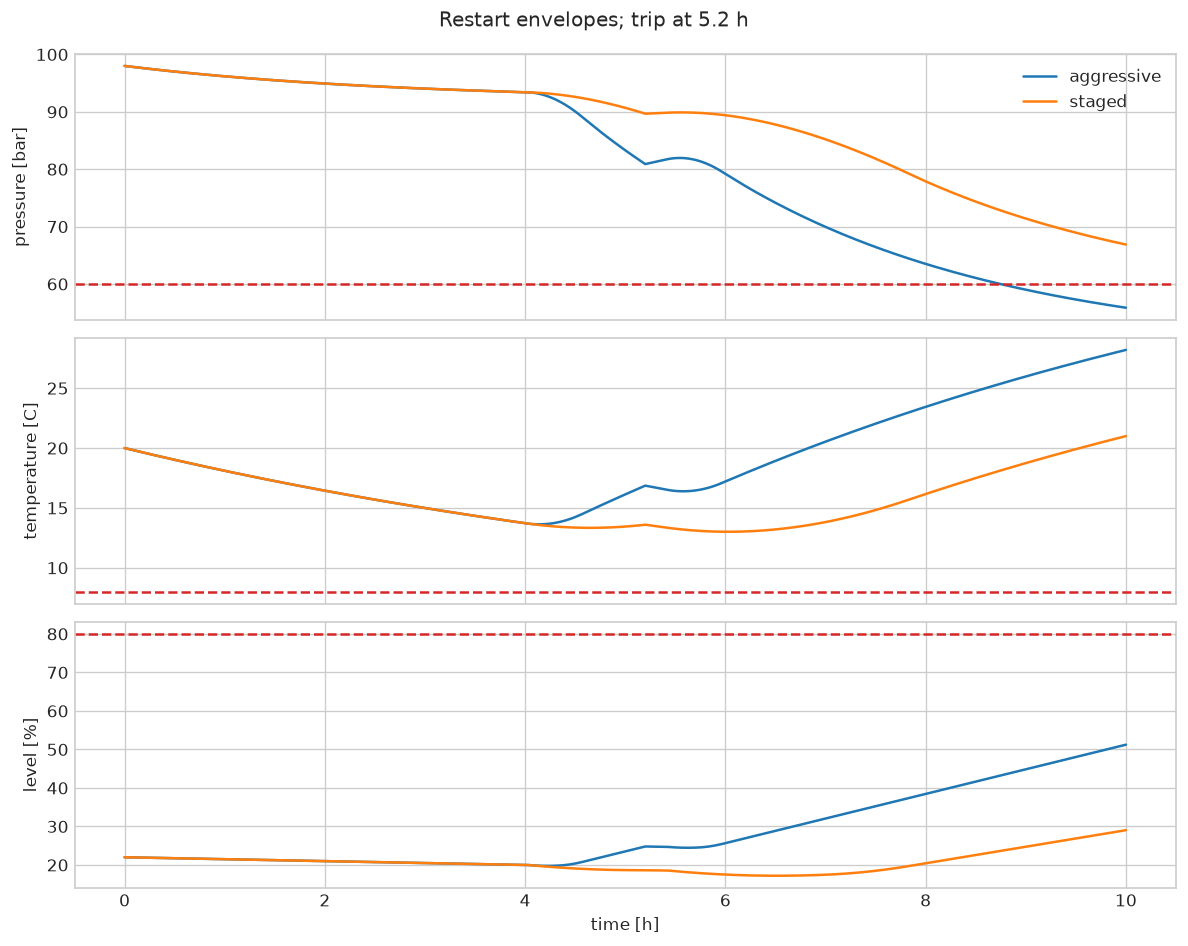

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for strategy, frame in transients.groupby("strategy"):
    axes[0].plot(frame.time_h, frame.pressure_bar, label=strategy)
    axes[1].plot(frame.time_h, frame.temperature_c, label=strategy)
    axes[2].plot(frame.time_h, frame.separator_level_pct, label=strategy)
axes[0].axhline(60, color="tab:red", linestyle="--")
axes[1].axhline(8, color="tab:red", linestyle="--")
axes[2].axhline(80, color="tab:red", linestyle="--")
axes[0].set_ylabel("pressure [bar]")
axes[1].set_ylabel("temperature [C]")
axes[2].set_ylabel("level [%]")
axes[2].set_xlabel("time [h]")
axes[0].legend()
fig.suptitle("Restart envelopes; trip at 5.2 h")
plt.tight_layout()
plt.show()


In [7]:
gate_by_strategy = gates.set_index("strategy")
assert bool(gate_by_strategy.loc["staged", "overall_pass"])
assert not bool(gate_by_strategy.loc["aggressive", "overall_pass"])
assert cold_liquid > 0.01
print("VALIDATION PASSED")
print("Recommendation: staged ramp with pressure and level hold points.")


VALIDATION PASSED
Recommendation: staged ramp with pressure and level hold points.


## Interpretation and limits

The staged procedure stays inside all three screening envelopes after
a compressor trip; the aggressive ramp does not. Replace the reduced
model with calibrated transient hydraulics, hydrate/wax checks, and
verified shutdown logic before issuing an operating procedure.
